<a href="https://colab.research.google.com/github/kbhrsiddhi1289/DeepLearningLab/blob/main/Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment No. 06

Name : Siddhi Maruti Kumbhar

Class : TYDS-10

PRN : 2324000255

Github Repo :

**CNN and Transfer Learning for Malaria Detection**

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import VGG16

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D

from tensorflow.keras.models import Model

import matplotlib.pyplot as plt

import numpy as np

import cv2
import os
import random

In [4]:
dataset_path = "/content/drive/MyDrive/malaria"

In [5]:
print(os.listdir(dataset_path))

['training', 'testing', 'validation']


In [6]:
train_path = dataset_path + "/training"

test_path = dataset_path + "/testing"

validation_path = dataset_path + "/validation"

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [8]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

validation_data = test_datagen.flow_from_directory(
    validation_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 360 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


In [9]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [10]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128,
          activation='relu')(x)

x = Dropout(0.5)(x)

predictions = Dense(1,
                    activation='sigmoid')(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=5
)

Epoch 1/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 290s 24s/step - accuracy: 0.4944 - loss: 0.7449 - val_accuracy: 0.5500 - val_loss: 0.6636
Epoch 2/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 253s 21s/step - accuracy: 0.5667 - loss: 0.6903 - val_accuracy: 0.7250 - val_loss: 0.6489
Epoch 3/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 264s 22s/step - accuracy: 0.5889 - loss: 0.6564 - val_accuracy: 0.7250 - val_loss: 0.6304
Epoch 4/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 271s 24s/step - accuracy: 0.6028 - loss: 0.6496 - val_accuracy: 0.7000 - val_loss: 0.6261
Epoch 5/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 265s 22s/step - accuracy: 0.6722 - loss: 0.6235 - val_accuracy: 0.7500 - val_loss: 0.6025


In [13]:
loss, accuracy = model.evaluate(test_data)

print("Accuracy:", accuracy)

print("Loss:", loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 70s 15s/step - accuracy: 0.6900 - loss: 0.5909
Accuracy: 0.6899999976158142
Loss: 0.5909390449523926


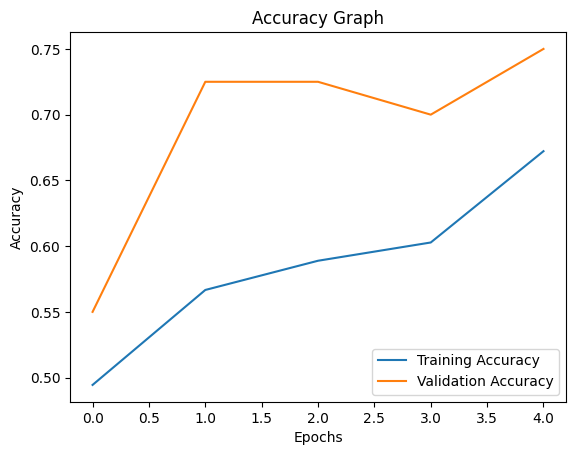

In [14]:
plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.legend()

plt.title("Accuracy Graph")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.show()

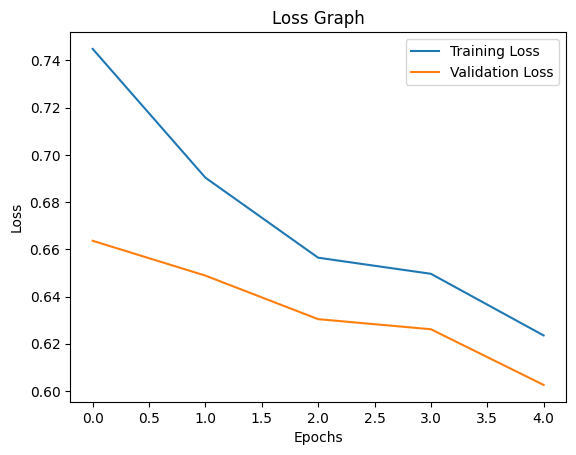

In [15]:
plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.legend()

plt.title("Loss Graph")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step


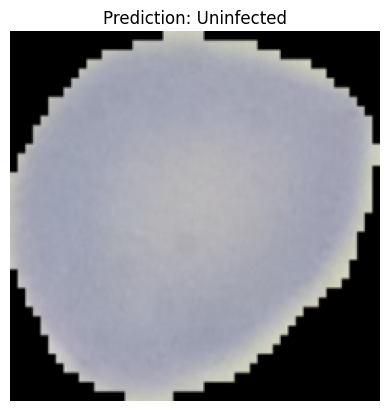

Predicted Result: Uninfected


In [16]:
random_class = random.choice(
    ['Parasitized', 'Uninfected']
)

folder_path = f"{test_path}/{random_class}"

random_image = random.choice(
    os.listdir(folder_path)
)

image_path = f"{folder_path}/{random_image}"

img = cv2.imread(image_path)

img_resized = cv2.resize(img, (224,224))

img_normalized = img_resized / 255.0

img_input = np.expand_dims(
    img_normalized,
    axis=0
)

prediction = model.predict(img_input)

plt.imshow(
    cv2.cvtColor(img_resized,
                 cv2.COLOR_BGR2RGB)
)

if prediction[0][0] > 0.5:
    result = "Uninfected"
else:
    result = "Parasitized"

plt.title(f"Prediction: {result}")

plt.axis('off')

plt.show()

print("Predicted Result:", result)